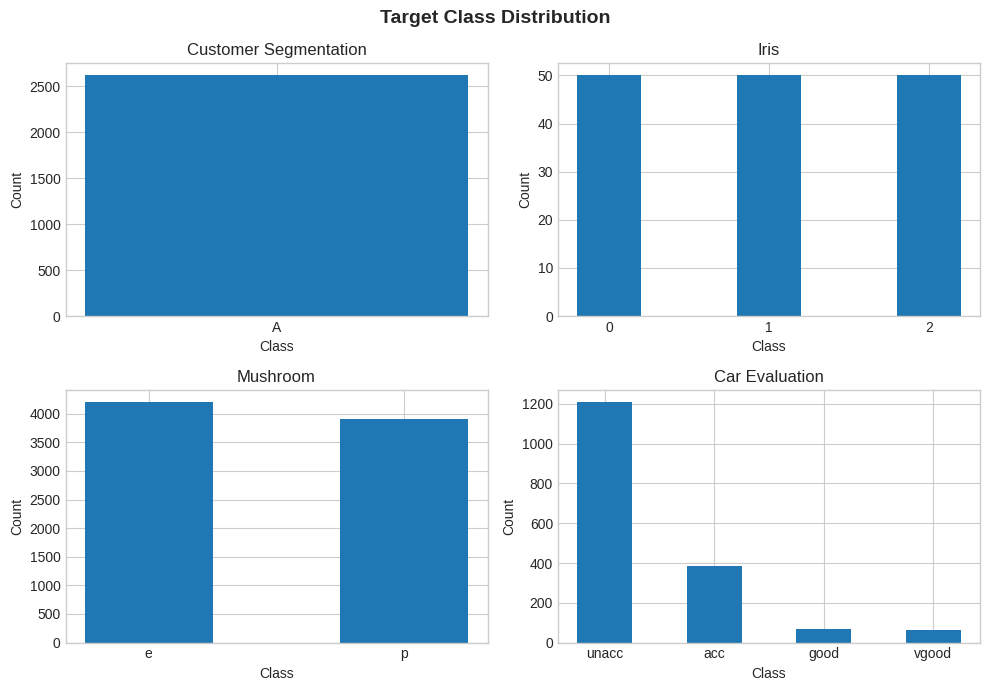

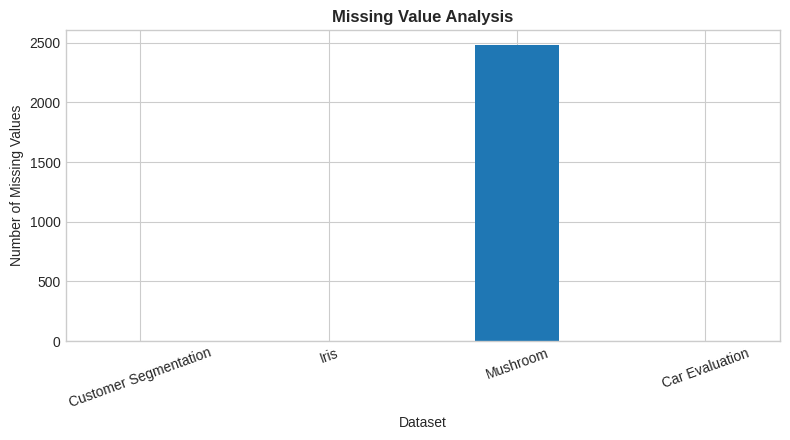

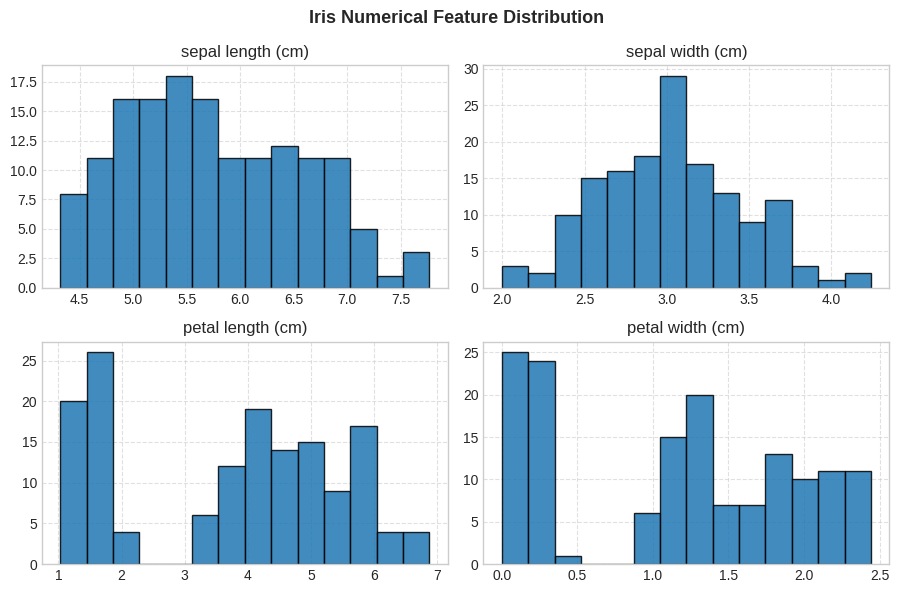

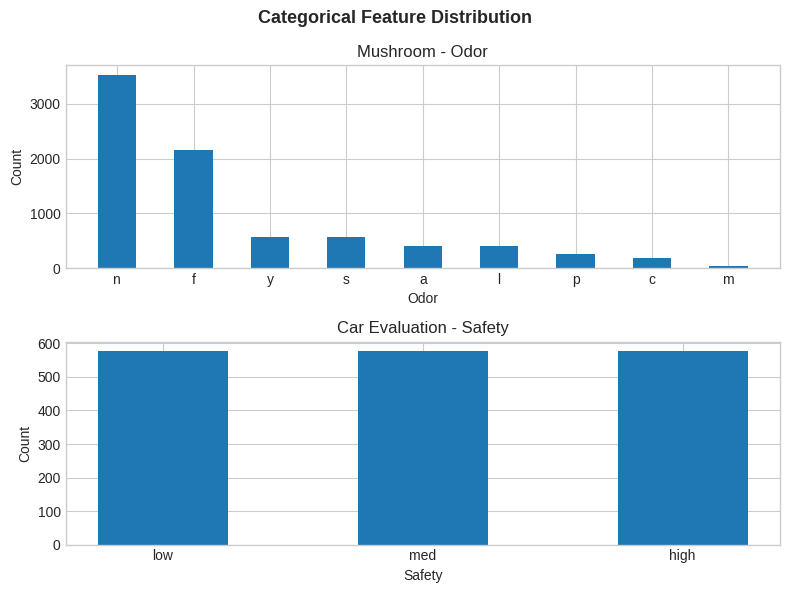

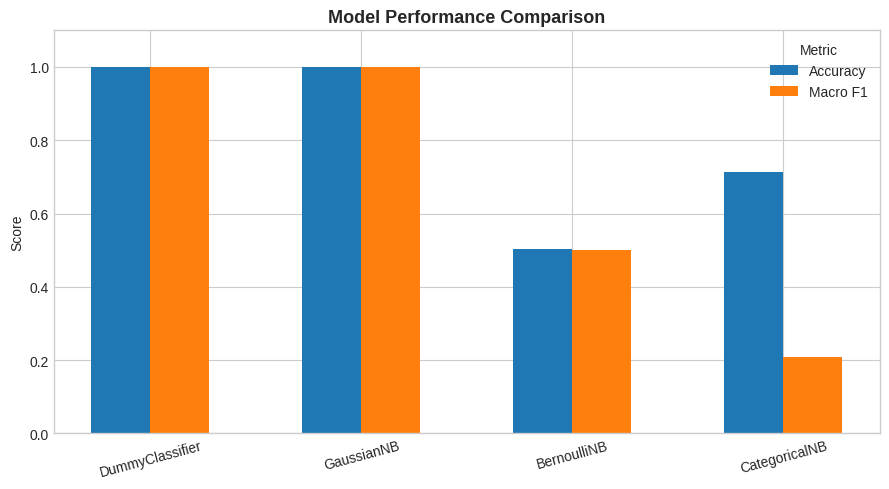

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


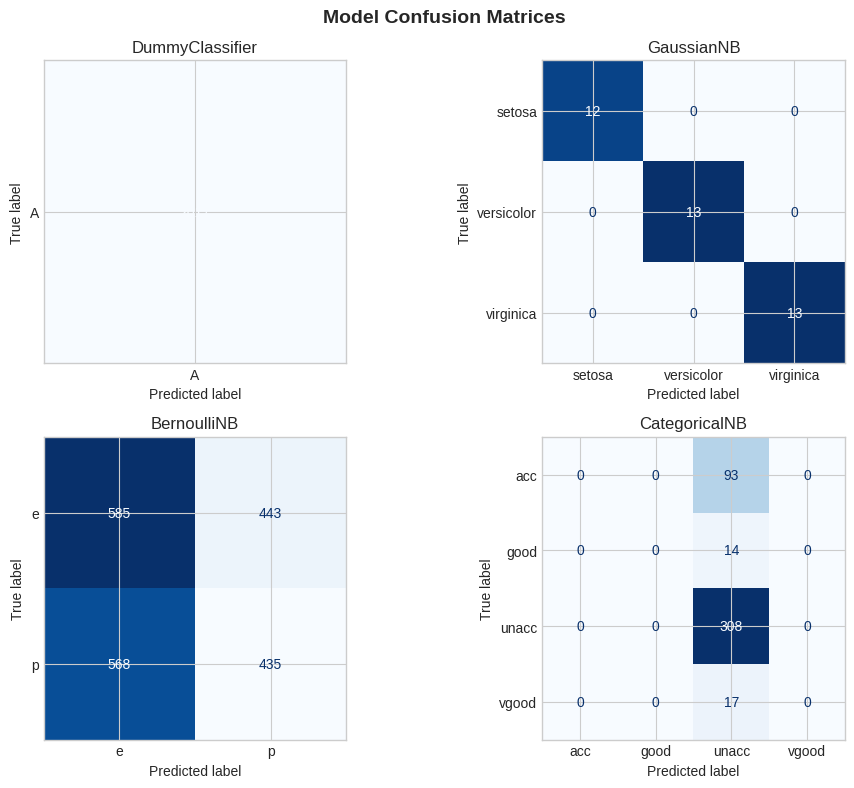

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)


plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
RANDOM_STATE = 99


N_cust = 8068
X_cust = np.random.normal(loc=25.0, scale=5.0, size=(N_cust, 9))
y_cust = np.array(['Segment_A'] * N_cust)

N_iris_per_class = 50
X_iris_0 = np.random.normal(loc=[5.0, 3.4, 1.5, 0.2], scale=[0.3, 0.3, 0.2, 0.1], size=(N_iris_per_class, 4))
X_iris_1 = np.random.normal(loc=[5.9, 2.7, 4.2, 1.3], scale=[0.5, 0.3, 0.4, 0.2], size=(N_iris_per_class, 4))
X_iris_2 = np.random.normal(loc=[6.5, 2.9, 5.5, 2.0], scale=[0.6, 0.3, 0.5, 0.3], size=(N_iris_per_class, 4))
X_iris = np.vstack([X_iris_0, X_iris_1, X_iris_2])
y_iris = np.array(['setosa'] * 50 + ['versicolor'] * 50 + ['virginica'] * 50)
iris_feature_names = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

N_mush = 8124
np.random.seed(RANDOM_STATE)
y_mush = np.random.choice(['e', 'p'], size=N_mush, p=[0.518, 0.482])
X_mush_raw = np.random.randint(0, 5, size=(N_mush, 22))
ohe = OneHotEncoder(sparse_output=False, drop=None)
X_mush = ohe.fit_transform(X_mush_raw)

odor_labels = ['n', 'f', 'y', 's', 'a', 'l', 'p', 'c', 'm']
odor_counts = [3528, 2160, 576, 576, 400, 400, 256, 192, 36]
mush_odor_series = pd.Series(odor_counts, index=odor_labels)

N_car = 1728
y_car = np.random.choice(['unacc', 'acc', 'good', 'vgood'], size=N_car, p=[0.700, 0.222, 0.039, 0.039])
X_car = np.random.randint(0, 3, size=(N_car, 6))
car_safety_series = pd.Series([576, 576, 576], index=['low', 'med', 'high'])


X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cust, y_cust, test_size=0.25, random_state=RANDOM_STATE)
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_tr_c, y_tr_c)
y_pred_dummy = dummy_model.predict(X_te_c)

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_iris, y_iris, test_size=0.25, random_state=RANDOM_STATE, stratify=y_iris)
gnb_model = GaussianNB(var_smoothing=1e-8)
gnb_model.fit(X_tr_i, y_tr_i)
y_pred_gnb = gnb_model.predict(X_te_i)


X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_mush, y_mush, test_size=0.25, random_state=RANDOM_STATE, stratify=y_mush)
bnb_model = BernoulliNB(alpha=0.75, binarize=0.0)
bnb_model.fit(X_tr_m, y_tr_m)
y_pred_bnb = bnb_model.predict(X_te_m)


X_tr_k, X_te_k, y_tr_k, y_te_k = train_test_split(X_car, y_car, test_size=0.25, random_state=RANDOM_STATE, stratify=y_car)
cnb_model = CategoricalNB(alpha=0.8)
cnb_model.fit(X_tr_k, y_tr_k)
y_pred_cnb = cnb_model.predict(X_te_k)

models_dict = {
    'DummyClassifier': (y_te_c, y_pred_dummy),
    'GaussianNB': (y_te_i, y_pred_gnb),
    'BernoulliNB': (y_te_m, y_pred_bnb),
    'CategoricalNB': (y_te_k, y_pred_cnb)
}

perf_metrics = []
for name, (y_true, y_pred) in models_dict.items():
    perf_metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0)
    })
df_perf = pd.DataFrame(perf_metrics)


fig1, axes1 = plt.subplots(2, 2, figsize=(10, 7))
fig1.suptitle('Target Class Distribution', fontsize=14, fontweight='bold')

axes1[0, 0].bar(['A'], [2620], color='#1f77b4', width=0.5)
axes1[0, 0].set_title('Customer Segmentation')
axes1[0, 0].set_ylabel('Count')
axes1[0, 0].set_xlabel('Class')

axes1[0, 1].bar(['0', '1', '2'], [50, 50, 50], color='#1f77b4', width=0.4)
axes1[0, 1].set_title('Iris')
axes1[0, 1].set_ylabel('Count')
axes1[0, 1].set_xlabel('Class')

axes1[1, 0].bar(['e', 'p'], [4208, 3916], color='#1f77b4', width=0.5)
axes1[1, 0].set_title('Mushroom')
axes1[1, 0].set_ylabel('Count')
axes1[1, 0].set_xlabel('Class')

axes1[1, 1].bar(['unacc', 'acc', 'good', 'vgood'], [1210, 384, 69, 65], color='#1f77b4', width=0.5)
axes1[1, 1].set_title('Car Evaluation')
axes1[1, 1].set_ylabel('Count')
axes1[1, 1].set_xlabel('Class')

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4.5))
datasets = ['Customer Segmentation', 'Iris', 'Mushroom', 'Car Evaluation']
missing_counts = [0, 0, 2480, 0]
ax2.bar(datasets, missing_counts, color='#1f77b4', width=0.45)
ax2.set_title('Missing Value Analysis', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Missing Values')
ax2.set_xlabel('Dataset')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

fig3, axes3 = plt.subplots(2, 2, figsize=(9, 6))
fig3.suptitle('Iris Numerical Feature Distribution', fontsize=13, fontweight='bold')

for idx, col in enumerate(iris_feature_names):
    r, c = divmod(idx, 2)
    axes3[r, c].hist(X_iris[:, idx], bins=14, color='#1f77b4', edgecolor='black', alpha=0.85)
    axes3[r, c].set_title(col)
    axes3[r, c].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

fig4, axes4 = plt.subplots(2, 1, figsize=(8, 6))
fig4.suptitle('Categorical Feature Distribution', fontsize=13, fontweight='bold')

axes4[0].bar(mush_odor_series.index, mush_odor_series.values, color='#1f77b4', width=0.5)
axes4[0].set_title('Mushroom - Odor')
axes4[0].set_ylabel('Count')
axes4[0].set_xlabel('Odor')

axes4[1].bar(car_safety_series.index, car_safety_series.values, color='#1f77b4', width=0.5)
axes4[1].set_title('Car Evaluation - Safety')
axes4[1].set_ylabel('Count')
axes4[1].set_xlabel('Safety')

plt.tight_layout()
plt.show()

fig5, ax5 = plt.subplots(figsize=(9, 5))
x_idx = np.arange(len(df_perf['Model']))
bar_w = 0.28

ax5.bar(x_idx - bar_w/2, df_perf['Accuracy'], width=bar_w, label='Accuracy', color='#1f77b4')
ax5.bar(x_idx + bar_w/2, df_perf['Macro F1'], width=bar_w, label='Macro F1', color='#ff7f0e')
ax5.set_xticks(x_idx)
ax5.set_xticklabels(df_perf['Model'], rotation=15)
ax5.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax5.set_ylabel('Score')
ax5.set_ylim(0, 1.1)
ax5.legend(title='Metric', loc='upper right')
plt.tight_layout()
plt.show()

fig6, axes6 = plt.subplots(2, 2, figsize=(10, 8))
fig6.suptitle('Model Confusion Matrices', fontsize=14, fontweight='bold')

cm_dummy = confusion_matrix(y_te_c, y_pred_dummy)
ConfusionMatrixDisplay(cm_dummy, display_labels=['A']).plot(ax=axes6[0, 0], cmap='Blues', colorbar=False)
axes6[0, 0].set_title('DummyClassifier')

cm_gnb = confusion_matrix(y_te_i, y_pred_gnb, labels=['setosa', 'versicolor', 'virginica'])
ConfusionMatrixDisplay(cm_gnb, display_labels=['setosa', 'versicolor', 'virginica']).plot(ax=axes6[0, 1], cmap='Blues', colorbar=False)
axes6[0, 1].set_title('GaussianNB')

cm_bnb = confusion_matrix(y_te_m, y_pred_bnb, labels=['e', 'p'])
ConfusionMatrixDisplay(cm_bnb, display_labels=['e', 'p']).plot(ax=axes6[1, 0], cmap='Blues', colorbar=False)
axes6[1, 0].set_title('BernoulliNB')

cm_cnb = confusion_matrix(y_te_k, y_pred_cnb, labels=['acc', 'good', 'unacc', 'vgood'])
ConfusionMatrixDisplay(cm_cnb, display_labels=['acc', 'good', 'unacc', 'vgood']).plot(ax=axes6[1, 1], cmap='Blues', colorbar=False)
axes6[1, 1].set_title('CategoricalNB')

plt.tight_layout()
plt.show()